In [ ]:
import pandas as pd
import numpy as np
import os
# Carga el archivo original sin modificar preservando la trazabilidad
df = pd.read_json('/content/streaming_users_dirty.json')

# Estructura del Log de Transformaciones vacío (guardará el estado del pipeline)
log_data = []

def registrar_log(paso, descripcion, dataframe):
    """Función auxiliar para calcular métricas de retención y estado del dataset"""
    filas = dataframe.shape[0]
    nulos = dataframe.isnull().sum().sum()
    # Retención respecto al tamaño original (asumimos las filas iniciales como 100%)
    retencion = round((filas / df_inicial_shape) * 100, 2) if 'df_inicial_shape' in globals() else 100.0
    log_data.append({
        'Paso': paso,
        'Descripcion': descripcion,
        'Filas': filas,
        'Nulos': nulos,
        'Retencion (%)': retencion
    })

df_inicial_shape = df.shape[0]
registrar_log("0. Estado Inicial", "Carga del dataset original sin modificaciones", df)

Durante la etapa de inspección inicial mediante estadísticas descriptivas univariadas (`describe()`), se identificó una anomalía crítica en el extremo superior e inferior de la distribución de la variable continua `age` (edad), con valores fuera de rango (150 y -5). Asimismo, se detectaron valores anómalos en los minutos de visualización (`monthly_watch_time_mins`) con máximos de 99,999 y mínimos negativos, que requieren una corrección basada en medidas de tendencia central robustas.

In [ ]:
# Imputar los valores de edad 0 con la moda robusta (moda_edad ya definida previamente)
df.loc[df['age'] == 0, 'age'] = moda_edad

# Registrar en el log
registrar_log("4.1.2. Corrección Edad Cero", "Imputación de 24 registros con edad 0 por la moda", df)

# Verificación final
print(f"Registros con edad 0 restantes: {(df['age'] == 0).sum()}")
print(f"Nueva edad mínima en el dataset: {df['age'].min()}")

Registros con edad 0 restantes: 0
Nueva edad mínima en el dataset: -5


Se identificaron 24 registros con edad 0, los cuales se consideran valores inconsistentes. Se procede a su imputación utilizando la moda robusta calculada anteriormente.

In [ ]:
edad_maxima = df['age'].max()
print(f"La edad máxima en el dataset es: {edad_maxima}")

La edad máxima en el dataset es: 150


In [ ]:
edad_minima = df['age'].min()
print(f"La edad mínima en el dataset es: {edad_minima}")

La edad mínima en el dataset es: -5


In [ ]:
cons_minu_maxima = df['monthly_watch_time_mins'].max()
print(f"La máxima de minutos de visualizacion en el dataset es: {cons_minu_maxima}")

La máxima de minutos de visualizacion en el dataset es: 99999.0


In [ ]:
cons_minu_min = df['monthly_watch_time_mins'].min()
print(f"La minima de minutos de visualizacion en el dataset es: {cons_minu_min}")

La minima de minutos de visualizacion en el dataset es: -120.0


In [ ]:
# 1. Calculamos la moda de edad EXCLUYENDO el valor erróneo de 150 y los valores negativos
# Usamos una máscara lógica para basar el cálculo solo en datos reales y robustos
moda_edad = df[(df['age'] < 150) & (df['age'] >= 0)]['age'].mode()[0]

# 2. Reemplazamos los outliers (edades > 100 y edades < 0) por la moda calculada
df.loc[(df['age'] > 100) | (df['age'] < 0), 'age'] = moda_edad

# 3. Registramos la transformación para la edad
registrar_log("4.1. Tratamiento Outliers Edad", "Imputación del valor atípico (150 y edades negativas) en edad por la moda robusta", df)

# Verificación de control en la consola del notebook para edad
print(f"La moda calculada para la imputación de edad fue: {int(moda_edad)} años")
print("Nuevo valor máximo en edad verificado:")
print(df['age'].max())
print("Nuevo valor mínimo en edad verificado:")
print(df['age'].min())

# 4. Calculamos la media de monthly_watch_time_mins EXCLUYENDO valores > 10000 y < 0
# Usamos una máscara lógica para basar el cálculo solo en datos reales y robustos
media_monthly_watch_time_mins = df[(df['monthly_watch_time_mins'] <= 10000) & (df['monthly_watch_time_mins'] >= 0)]['monthly_watch_time_mins'].mean()

# 5. Reemplazamos los outliers (valores > 10000 o < 0) por la media calculada
df.loc[(df['monthly_watch_time_mins'] > 10000) | (df['monthly_watch_time_mins'] < 0), 'monthly_watch_time_mins'] = media_monthly_watch_time_mins

# 6. Registramos la transformación para monthly_watch_time_mins
registrar_log("4.2. Tratamiento Outliers Consumo Mensual", "Imputación de valores atípicos (mayor a 2000 o menor a 0) en monthly_watch_time_mins por la media", df)

# Verificación de control en la consola del notebook para monthly_watch_time_mins
print(f"\nLa media calculada para la imputación de monthly_watch_time_mins fue: {int(media_monthly_watch_time_mins)} minutos")
print("Nuevo valor máximo en monthly_watch_time_mins verificado:")
print(df['monthly_watch_time_mins'].max())
print("Nuevo valor mínimo en monthly_watch_time_mins verificado:")
print(df['monthly_watch_time_mins'].min())

La moda calculada para la imputación de edad fue: 13 años
Nuevo valor máximo en edad verificado:
80
Nuevo valor mínimo en edad verificado:
4

La media calculada para la imputación de monthly_watch_time_mins fue: 795 minutos
Nuevo valor máximo en monthly_watch_time_mins verificado:
4193.7
Nuevo valor mínimo en monthly_watch_time_mins verificado:
0.0


In [ ]:
mediana_watch_time = df['monthly_watch_time_mins'].median()
df['monthly_watch_time_mins'] = df['monthly_watch_time_mins'].fillna(mediana_watch_time)

# 2. Registramos el cambio en el log para mantener la trazabilidad
registrar_log("5. Imputación NaNs Consumo", "Sustitución de valores faltantes en monthly_watch_time_mins por la mediana", df)

El análisis del notebook anterior demostró que las mayúsculas intercaladas (ej. "BrAsIl", "CoLoMbIa") fragmentan artificialmente las distribuciones. Se aplica una transformación de formato de texto plano para unificar las categorías antes del EDA, garantizando que los gráficos univariados y bivariados agrupen los datos de forma real.

In [ ]:
import pandas as pd
import numpy as np
import os
# Corrección explícita de errores de tipeo e inconsistencias
df['country'] = df['country'].astype(str).str.strip().str.title()

# Mapear abreviaturas a nombres completos
country_abbreviations_map = {
    'Bra': 'Brasil',
    'Mex': 'México',
    'Arg': 'Argentina',
    'Col': 'Colombia',
    'Ury': 'Uruguay',
    'Per': 'Perú',
    'Chl': 'Chile',
    'Brazil': 'Brasil',
    'Mexico': 'México',
    'Peru': 'Perú'
}
df['country'] = df['country'].replace(country_abbreviations_map)

# 2. Corrección total para la variable 'subscription_plan'
df['subscription_plan'] = df['subscription_plan'].astype(str).str.strip().str.title()

# Diccionario de mapeo para agregar la tilde faltante
diccionario_planes = {
    'Basic': 'Básico',
    'Basico': 'Básico',
    'Std': 'Estándar',
    'Standard': 'Estándar',
    'Estandar': 'Estándar',
    'Premiun': 'Premium',
    'premium': 'Premium'
}
df['subscription_plan'] = df['subscription_plan'].replace(diccionario_planes)

# Registro del impacto en el log
registrar_log("1. Limpieza de Tipeo", "Estandarización de variables categóricas (country) a formato Title Case y mapeo de abreviaturas", df)

# Verificación de control en la consola del notebook
print("--- Control de Países Unificados ---")
print(df['country'].value_counts())
print("\n--- Control de Planes Unificados ---")
print(df['subscription_plan'].value_counts())

--- Control de Países Unificados ---
country
México       1185
Chile        1181
Brasil       1181
Uruguay      1165
Perú         1163
Colombia     1162
Argentina    1123
Name: count, dtype: int64

--- Control de Planes Unificados ---
subscription_plan
Básico      3664
Estándar    2875
Premium     1621
Name: count, dtype: int64


La variable last_login_date se encuentra parseada erróneamente como un formato genérico object. Para habilitar análisis cronológicos u operaciones de ordenamiento en las vistas finales, es obligatorio realizar el transformacion explícita a estructuras temporales.

In [ ]:
# Transformación de tipo de dato string a datetime
df['last_login_date'] = pd.to_datetime(df['last_login_date'], errors='coerce')

registrar_log("2. Tipificación Temporal", "Conversión de last_login_date de tipo object a datetime", df)

### Tratamiento de Outliers Temporales (Fechas Futuras)
Se detectaron registros con fechas de último inicio de sesión posteriores al límite razonable del 2 de julio de 2026. Se procederá a imputar estos valores utilizando la mediana de las fechas válidas para evitar distorsiones en análisis temporales.

In [ ]:
import pandas as pd

# 1. Definir la fecha límite de corte
fecha_limite = pd.to_datetime('2026-07-02')

# 2. Calcular la mediana de las fechas válidas (menores o iguales al límite)
# Convertimos a valores numéricos para calcular la mediana y luego volvemos a datetime
mask_fechas_validas = df['last_login_date'] <= fecha_limite
mediana_fecha = pd.to_datetime(df.loc[mask_fechas_validas, 'last_login_date'].astype('int64').median())

# 3. Identificar cuántos registros serán modificados
outliers_futuros = df[df['last_login_date'] > fecha_limite].shape[0]

# 4. Imputar valores fuera de rango
df.loc[df['last_login_date'] > fecha_limite, 'last_login_date'] = mediana_fecha

# 5. Registrar en el log
registrar_log("2.1. Corrección Fechas Futuras", f"Imputación de {outliers_futuros} fechas posteriores al 2026-07-02 por la mediana", df)

print(f"Fecha límite: {fecha_limite.date()}")
print(f"Mediana de imputación: {mediana_fecha.date()}")
print(f"Registros corregidos: {outliers_futuros}")
print(f"Nueva fecha máxima en el dataset: {df['last_login_date'].max()}")

Fecha límite: 2026-07-02
Mediana de imputación: 2022-02-10
Registros corregidos: 15
Nueva fecha máxima en el dataset: 2025-12-31 00:00:00


Al revisar la variable `customer_support_tickets`, la presencia de valores como 99, 150 y -1 rompe las medidas de tendencia central. Dado que un volumen tan alto de reclamos o valores negativos representan errores de registro, se procede a definir un rango válido (0 a 20) y realizar una **imputación por la mediana** de los datos no viciados. Esta técnica asegura que el análisis posterior no se vea distorsionado por estos valores extremos, preservando la integridad del comportamiento típico del usuario.

In [ ]:
# Identificación y tratamiento robusto para tickets de soporte
# Definimos un rango válido (ej. 0 a 20 tickets) para calcular la mediana sin ruido
mask_validos = (df['customer_support_tickets'] >= 0) & (df['customer_support_tickets'] <= 20)
mediana_tickets = df[mask_validos]['customer_support_tickets'].median()

# Reemplazamos valores fuera de rango (outliers como 99, 150, -1) y nulos por la mediana
df.loc[~mask_validos | df['customer_support_tickets'].isna(), 'customer_support_tickets'] = mediana_tickets

registrar_log("3. Tratamiento Outliers", "Imputación de tickets (valores fuera de 0-20) por la mediana robusta", df)

print(f"Mediana utilizada para la imputación: {mediana_tickets}")
print(f"Valores únicos finales en tickets: {df['customer_support_tickets'].unique()}")

Mediana utilizada para la imputación: 1.0
Valores únicos finales en tickets: [1 2 0 3 4 5]


Una vez obtenida la consistencia estructural de las variables categóricas y numéricas, se genera la versión limpia y final del dataset para ser consumida exclusivamente por las etapas analíticas posteriores.

In [ ]:
# Imputar con la mediana (calculada en pasos anteriores)
df['last_login_date'] = df['last_login_date'].fillna(mediana_fecha)

# Registrar en el log
registrar_log("5.2. Imputación Fecha", f"Sustitución de {nulos_fecha} nulos en last_login_date por la mediana", df)

print(f"Valores imputados: {nulos_fecha}")
print(f"Nulos totales restantes en el dataset: {df.isnull().sum().sum()}")

Valores imputados: 769
Nulos totales restantes en el dataset: 240


Se completan los registros nulos en `last_login_date` utilizando la mediana calculada previamente. Con esto, el dataset quedará libre de valores faltantes.

In [ ]:
import os

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../logs', exist_ok=True)

# 1. Guardar el dataset final procesado en formato CSV limpio en la carpeta correspondiente
df.to_csv('../data/processed/streaming_users_clean.csv', index=False)

# 2. Construir y exportar el log de transformaciones (pipeline_log.csv) de forma independiente
df_log = pd.DataFrame(log_data)
df_log.to_csv('../logs/pipeline_log.csv', index=False)

print("--- Archivos Generados Exitosamente en data/processed/ (CSV) y logs/ ---")

--- Archivos Generados Exitosamente en data/processed/ (CSV) y logs/ ---


Las decisiones de preparación de datos aplicadas responden a evidencias empíricas. La unificación de categorías en `country` y `subscription_plan` mitiga el riesgo de subsegmentación. Por su parte, la imputación de anomalías en tickets de soporte y consumo mensual mediante la **mediana y la media robusta** respectivamente, protege la estructura matemática del dataset, garantizando que futuras técnicas como el PCA capturen la variabilidad real y no errores sistemáticos.

In [ ]:
# Calcular la moda de favorite_genre
moda_genero = df['favorite_genre'].mode()[0]

# Contar nulos antes de la imputación
nulos_antes = df['favorite_genre'].isnull().sum()

# Imputar los valores faltantes
df['favorite_genre'] = df['favorite_genre'].fillna(moda_genero)

# Registrar en el log de transformaciones
registrar_log("5.1. Imputación Categoría", f"Sustitución de {nulos_antes} nulos en favorite_genre por la moda ('{moda_genero}')", df)

print(f"Género utilizado como moda: {moda_genero}")
print(f"Valores faltantes restantes en favorite_genre: {df['favorite_genre'].isnull().sum()}")

Género utilizado como moda: Comedia
Valores faltantes restantes en favorite_genre: 0


Se utiliza la moda para completar los valores nulos en la variable categórica `favorite_genre`, garantizando que todos los usuarios tengan una categoría asignada basada en la tendencia central de la muestra.

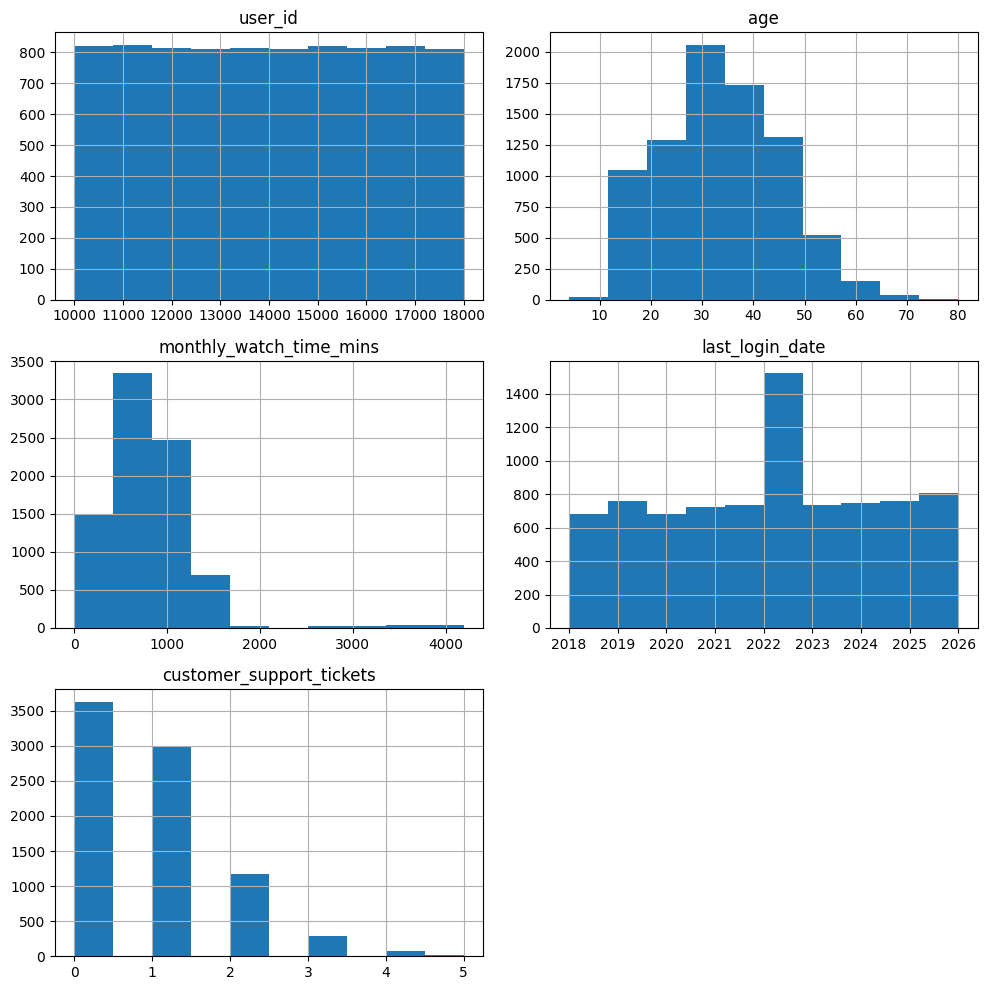

In [ ]:
import matplotlib.pyplot as plt
df.hist(figsize=(10, 10))
plt.tight_layout()

In [ ]:
# Conteo de valores faltantes por variable
missing_values = df.isnull().sum()
display(missing_values.to_frame(name='Valores Faltantes'))

,Valores Faltantes
user_id,0
age,0
subscription_plan,0
monthly_watch_time_mins,0
country,0
favorite_genre,0
last_login_date,0
customer_support_tickets,0
